Calibration_Pre_Post_Deforestation


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from Weigfun import Weigfun   # must be in same folder


shape_area_manning = 6642 * 1e6  # m²

# --- Evaporation ---
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily["Date"] = pd.to_datetime(evap_daily["system:index"], format="%Y%m%d")
evap_daily = evap_daily.set_index("Date")[["total_evaporation_sum"]]
evap_daily = evap_daily.rename(columns={"total_evaporation_sum": "Etp"})
evap_daily["Etp"] = evap_daily["Etp"].abs() * 1000  # m/day → mm/day

# --- Precipitation ---
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily["Date"] = pd.to_datetime(precip_daily["system:index"], format="%Y%m%d")
precip_daily = precip_daily.set_index("Date")[["total_precipitation_sum"]]
precip_daily = precip_daily.rename(columns={"total_precipitation_sum": "Prec"})
precip_daily["Prec"] = precip_daily["Prec"] * 1000  # m/day → mm/day

# --- Discharge ---
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True,
)
Obs = Obs.rename(columns={" Value": "Qo"})
Obs.loc[Obs["Qo"] > 4000, "Qo"] = np.nan
Obs.loc[Obs["Qo"] < 0, "Qo"] = np.nan
Obs["Qo"] = Obs["Qo"] * 86400 / shape_area_manning * 1000  # m³/s → mm/day

# --- Merge forcing ---
data = (
    precip_daily[["Prec"]]
    .join(evap_daily[["Etp"]], how="inner")
    .join(Obs[["Qo"]], how="inner")
    .dropna()
)


def hillslope_func(t, Par, forcing, Fluxes, States):
    I_max, Ce, Su_max, beta, D, Kf = Par

    Prec = forcing["Prec"]
    Etp = forcing["Etp"]

    t_max = len(Prec)
    dt = 1

    Si = States[:, 0]
    Su = States[:, 1]
    Sf = States[:, 2]

    Ei_dt = Fluxes[:, 0]
    Ea_dt = Fluxes[:, 1]
    Qf_dt = Fluxes[:, 2]
    Qus_dt = Fluxes[:, 3]

    P_dt = Prec[t] * dt
    Ep_dt = Etp[t] * dt

    # --- Interception ---
    if P_dt > 0:
        Si[t] += P_dt
        Pe_dt = max(0, Si[t] - I_max)
        Si[t] -= Pe_dt
        Ei_dt[t] = 0
    else:
        Pe_dt = 0
        Ei_dt[t] = min(Ep_dt, Si[t])
        Si[t] -= Ei_dt[t]

    if t < t_max - 1:
        Si[t + 1] = Si[t]

    # --- Unsaturated zone ---
    if Pe_dt > 0:
        rho = (Su[t] / Su_max) ** beta
        Su[t] += (1 - rho) * Pe_dt
        Quf_dt = rho * Pe_dt
    else:
        Quf_dt = 0

    # --- Transpiration ---
    Ep_dt = max(0, Ep_dt - Ei_dt[t])
    Ea_dt[t] = Ep_dt * (Su[t] / (Su_max * Ce))
    Ea_dt[t] = min(Ea_dt[t], Su[t])
    Su[t] -= Ea_dt[t]

    if t < t_max - 1:
        Su[t + 1] = Su[t]

    # --- Preferential percolation ---
    Qus_dt[t] = D * Quf_dt

    # --- Fast reservoir ---
    Sf[t] += (1 - D) * Quf_dt
    Qf_dt[t] = Kf * Sf[t]
    Sf[t] -= min(Qf_dt[t], Sf[t])

    if t < t_max - 1:
        Sf[t + 1] = Sf[t]

    # Save
    States[:, 0] = Si
    States[:, 1] = Su
    States[:, 2] = Sf
    Fluxes[:, 0] = Ei_dt
    Fluxes[:, 1] = Ea_dt
    Fluxes[:, 2] = Qf_dt
    Fluxes[:, 3] = Qus_dt

    return Fluxes, States


def FLEXtopo_hillslope(ParHillslope, ParCatchment, forcing):
    Ks, Tlag = ParCatchment
    dt = 1
    t_max = len(forcing["Qo"])

    States = np.zeros((t_max, 3))
    Fluxes = np.zeros((t_max, 4))
    Ss = np.zeros(t_max)
    Q_tot = np.zeros(t_max)

    for t in range(t_max):
        Fluxes, States = hillslope_func(t, ParHillslope, forcing, Fluxes, States)

        # Slow reservoir
        Ss[t] += Fluxes[t, 3]
        Qs = Ks * Ss[t]
        Ss[t] -= min(Qs, Ss[t])

        if t < t_max - 1:
            Ss[t + 1] = Ss[t]

        Q_tot[t] = Qs + Fluxes[t, 2]

    # Routing
    weights = Weigfun(Tlag)
    Qm = np.convolve(Q_tot, weights)[:t_max]
    return np.maximum(Qm, 0)


def make_forcing(df):
    return {"Prec": df["Prec"].values, "Etp": df["Etp"].values, "Qo": df["Qo"].values}

def nse(sim, obs):
    sim = np.maximum(sim, 0)
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    return 1 - np.sum((obs[mask] - sim[mask]) ** 2) / np.sum((obs[mask] - np.mean(obs[mask])) ** 2)

def lognse(sim, obs):
    sim = np.maximum(sim, 1e-6)
    obs = np.maximum(obs, 1e-6)
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    return 1 - np.sum((np.log(obs[mask]) - np.log(sim[mask])) ** 2) / \
               np.sum((np.log(obs[mask]) - np.mean(np.log(obs[mask]))) ** 2)

def De_from_metrics(nse_val, lognse_val):
    return np.sqrt((1 - nse_val) ** 2 + (1 - lognse_val) ** 2)

def sample_theta(bounds):
    low = bounds[:, 0]
    high = bounds[:, 1]
    return low + (high - low) * np.random.rand(len(bounds))

def run_model(theta, forcing):
    ParH = theta[:6]
    ParC = theta[6:]
    return FLEXtopo_hillslope(ParH, ParC, forcing)


# parameter
param_names = ["Imax", "Ce", "Su_max", "beta", "D", "Kf", "Ks", "Tlag"]

param_bounds = np.array([
    (0, 5),      # Imax
    (0.1, 2),    # Ce
    (20, 400),   # Su_max
    (0.1, 5),    # beta
    (0, 1),      # D
    (0.001, 1),  # Kf
    (0.001, 1),  # Ks
    (0, 5),      # Tlag
])


# date ranges
pre_start, pre_end = "2014-01-01", "2019-10-01"
post_start, post_end = "2020-03-01", "2025-01-01"
warmup_days = 365

pre_data = data.loc[pre_start:pre_end]
post_data = data.loc[post_start:post_end]

warmup_pre = data.loc[(pd.to_datetime(pre_start) - pd.Timedelta(days=warmup_days)):pre_start]
warmup_post = data.loc[(pd.to_datetime(post_start) - pd.Timedelta(days=warmup_days)):post_start]

forcing_pre = make_forcing(pre_data)
forcing_post = make_forcing(post_data)
forcing_warmup_pre = make_forcing(warmup_pre)
forcing_warmup_post = make_forcing(warmup_post)


#obj func
def objective(theta, forcing, warmup):
    _ = run_model(theta, warmup)
    Qsim = run_model(theta, forcing)
    NSE = nse(Qsim, forcing["Qo"])
    LOGNSE = lognse(Qsim, forcing["Qo"])
    De = De_from_metrics(NSE, LOGNSE)
    return NSE, LOGNSE, De


#pre cal
n_runs = 500
thetas_pre = []
metrics_pre = []

for i in range(n_runs):
    theta = sample_theta(param_bounds)
    NSE_i, LOGNSE_i, De_i = objective(theta, forcing_pre, forcing_warmup_pre)
    thetas_pre.append(theta)
    metrics_pre.append((NSE_i, LOGNSE_i, De_i))

thetas_pre = np.array(thetas_pre)
metrics_pre = np.array(metrics_pre)

best_pre_nse_idx = np.nanargmax(metrics_pre[:, 0])
best_pre_lognse_idx = np.nanargmax(metrics_pre[:, 1])
best_pre_De_idx = np.nanargmin(metrics_pre[:, 2])

theta_pre_nse = thetas_pre[best_pre_nse_idx]
theta_pre_lognse = thetas_pre[best_pre_lognse_idx]
theta_pre_De = thetas_pre[best_pre_De_idx]


# pre val
def validate(theta, forcing, warmup):
    _ = run_model(theta, warmup)
    Qsim = run_model(theta, forcing)
    return (
        nse(Qsim, forcing["Qo"]),
        lognse(Qsim, forcing["Qo"]),
        De_from_metrics(nse(Qsim, forcing["Qo"]), lognse(Qsim, forcing["Qo"]))
    )

pre_val_nse = validate(theta_pre_nse, forcing_pre, forcing_warmup_pre)
pre_val_lognse = validate(theta_pre_lognse, forcing_pre, forcing_warmup_pre)
pre_val_De = validate(theta_pre_De, forcing_pre, forcing_warmup_pre)


# post cal
thetas_post = []
metrics_post = []

for i in range(n_runs):
    theta = sample_theta(param_bounds)
    NSE_i, LOGNSE_i, De_i = objective(theta, forcing_post, forcing_warmup_post)
    thetas_post.append(theta)
    metrics_post.append((NSE_i, LOGNSE_i, De_i))

thetas_post = np.array(thetas_post)
metrics_post = np.array(metrics_post)

best_post_nse_idx = np.nanargmax(metrics_post[:, 0])
best_post_lognse_idx = np.nanargmax(metrics_post[:, 1])
best_post_De_idx = np.nanargmin(metrics_post[:, 2])

theta_post_nse = thetas_post[best_post_nse_idx]
theta_post_lognse = thetas_post[best_post_lognse_idx]
theta_post_De = thetas_post[best_post_De_idx]


# post val
post_val_nse = validate(theta_post_nse, forcing_post, forcing_warmup_post)
post_val_lognse = validate(theta_post_lognse, forcing_post, forcing_warmup_post)
post_val_De = validate(theta_post_De, forcing_post, forcing_warmup_post)




In [2]:
summary = pd.DataFrame({
    "Metric": ["NSE", "logNSE", "De"],
    "Pre-Deforestation Calibration": [
        metrics_pre[best_pre_nse_idx, 0],
        metrics_pre[best_pre_lognse_idx, 1],
        metrics_pre[best_pre_De_idx, 2]
    ],
    "Pre-Deforestation Validation": [
        pre_val_nse[0],
        pre_val_lognse[1],
        pre_val_De[2]
    ],
    "Post-Deforestation Calibration": [
        metrics_post[best_post_nse_idx, 0],
        metrics_post[best_post_lognse_idx, 1],
        metrics_post[best_post_De_idx, 2]
    ],
    "Post-Deforestation Validation": [
        post_val_nse[0],
        post_val_lognse[1],
        post_val_De[2]
    ]
})

print(summary)

   Metric  Pre-Deforestation Calibration  Pre-Deforestation Validation  \
0     NSE                       0.452621                      0.452621   
1  logNSE                       0.012239                      0.012239   
2      De                       1.187839                      1.187839   

   Post-Deforestation Calibration  Post-Deforestation Validation  
0                        0.658549                       0.658549  
1                        0.211536                       0.211536  
2                        0.934235                       0.934235  


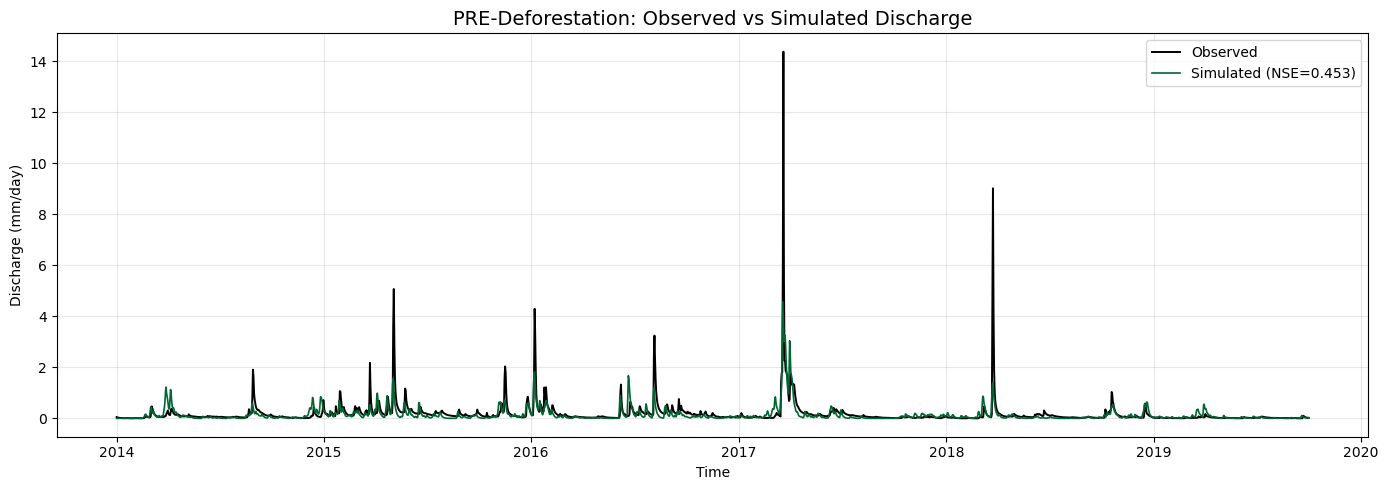

In [3]:
# Run warmup + simulation
_ = run_model(theta_pre_nse, forcing_warmup_pre)
Qsim_pre = run_model(theta_pre_nse, forcing_pre)

# Extract observed
Qobs_pre = forcing_pre["Qo"]
time_pre = pre_data.index

plt.figure(figsize=(14,5))
plt.plot(time_pre, Qobs_pre, label="Observed", color="black", linewidth=1.4)
plt.plot(time_pre, Qsim_pre, label="Simulated (NSE={:.3f})".format(pre_val_nse[0]), color="#006633", linewidth=1.2)

plt.title("PRE-Deforestation: Observed vs Simulated Discharge", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

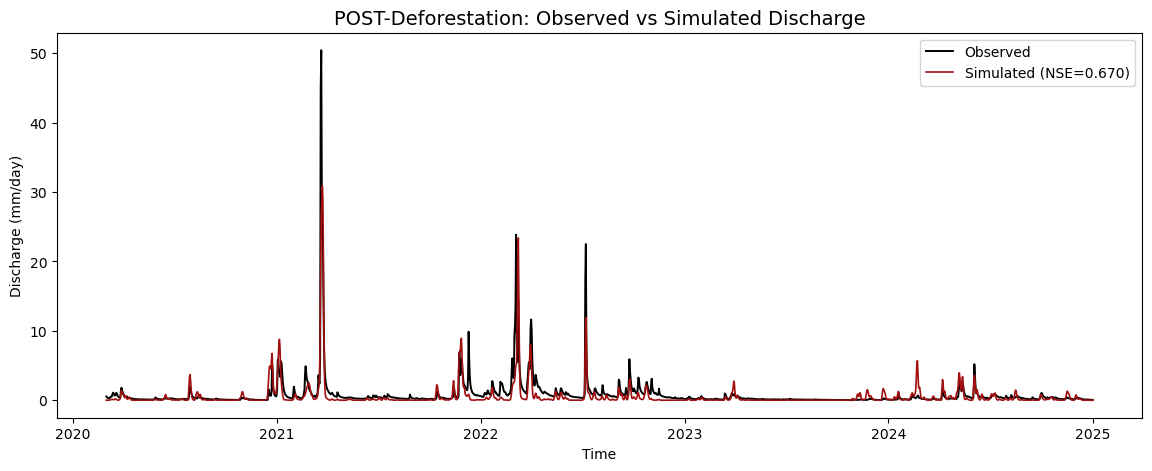

In [7]:
#plot for post deforestation
_ = run_model(theta_post_nse, forcing_warmup_post)
Qsim_post = run_model(theta_post_nse, forcing_post)
Qobs_post = forcing_post["Qo"]
time_post = post_data.index
plt.figure(figsize=(14,5))
plt.plot(time_post, Qobs_post, label="Observed", color="black", linewidth=1.4)
plt.plot(time_post, Qsim_post, label="Simulated (NSE={:.3f})".format(post_val_nse[0]), color="#a31010", linewidth=1.2)
plt.title("POST-Deforestation: Observed vs Simulated Discharge", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Discharge (mm/day)")
plt.legend()

In [4]:

def print_params(label, theta):
    print(f"\n--- {label} ---")
    for name, val in zip(param_names, theta):
        print(f"{name:8s} = {val:.4f}")
    print(f"Su_max  = {theta[2]:.4f} mm")   


print("\n==================== PARAMETER SETS (PRE-Deforestation) ====================")
print_params("PRE-Deforestation — Best NSE parameters",    theta_pre_nse)
print_params("PRE-Deforestation — Best logNSE parameters", theta_pre_lognse)
print_params("PRE-Deforestation — Best De parameters",     theta_pre_De)
print("\n==================== PARAMETER SETS (POST-Deforestation) ====================")
print_params("POST-Deforestation — Best NSE parameters",    theta_post_nse)
print_params("POST-Deforestation — Best logNSE parameters", theta_post_lognse)
print_params("POST-Deforestation — Best De parameters",     theta_post_De)



==================== PARAMETER SETS (PRE-Deforestation) ====================

--- PRE-Deforestation — Best NSE parameters ---
Imax     = 1.3357
Ce       = 0.3092
Su_max   = 349.3401
beta     = 2.5688
D        = 0.7485
Kf       = 0.8550
Ks       = 0.2594
Tlag     = 3.0634
Su_max  = 349.3401 mm

--- PRE-Deforestation — Best logNSE parameters ---
Imax     = 4.8158
Ce       = 0.2100
Su_max   = 92.2915
beta     = 1.6534
D        = 0.8479
Kf       = 0.0147
Ks       = 0.3778
Tlag     = 3.8298
Su_max  = 92.2915 mm

--- PRE-Deforestation — Best De parameters ---
Imax     = 4.8158
Ce       = 0.2100
Su_max   = 92.2915
beta     = 1.6534
D        = 0.8479
Kf       = 0.0147
Ks       = 0.3778
Tlag     = 3.8298
Su_max  = 92.2915 mm

==================== PARAMETER SETS (POST-Deforestation) ====================

--- POST-Deforestation — Best NSE parameters ---
Imax     = 1.0569
Ce       = 0.4564
Su_max   = 83.6001
beta     = 3.8709
D        = 0.6781
Kf       = 0.9482
Ks       = 0.8946
Tlag     = 4.9260

In [5]:
#give average of each validation metric across the 3 parameter sets for pre and post
avg_pre_val_nse = np.mean([pre_val_nse[0], pre_val_lognse[0], pre_val_De[0]])
avg_pre_val_lognse = np.mean([pre_val_nse[1], pre_val_lognse[1], pre_val_De[1]])
avg_pre_val_De = np.mean([pre_val_nse[2], pre_val_lognse[2], pre_val_De[2]])

print(f"Average pre NSE: {avg_pre_val_nse:.4f}")
print(f"Average pre logNSE: {avg_pre_val_lognse:.4f}")
print(f"Average pre De: {avg_pre_val_De:.4f}")
avg_post_val_nse = np.mean([post_val_nse[0], post_val_lognse[0], post_val_De[0]])
avg_post_val_lognse = np.mean([post_val_nse[1], post_val_lognse[1], post_val_De[1]])
avg_post_val_De = np.mean([post_val_nse[2], post_val_lognse[2], post_val_De[2]])

print(f"Average post NSE: {avg_post_val_nse:.4f}")
print(f"Average post logNSE: {avg_post_val_lognse:.4f}")
print(f"Average post De: {avg_post_val_De:.4f}")

Average pre NSE: 0.3777
Average pre logNSE: -0.3690
Average pre De: 1.5254
Average post NSE: 0.5521
Average post logNSE: -2.8449
Average post De: 3.9440


In [10]:
# BEST VALIDATION parameter sets


def best_validation_params(label, val_metrics, param_sets):
    """
    val_metrics: list of (NSE, logNSE, De)
    param_sets: list of theta arrays in same order
    """
    val_metrics = np.array(val_metrics)

    best_nse_idx = np.nanargmax(val_metrics[:, 0])
    best_lognse_idx = np.nanargmax(val_metrics[:, 1])
    best_De_idx = np.nanargmin(val_metrics[:, 2])

    print("\n--- Best VALIDATION NSE parameters ---")
    print(pd.Series(param_sets[best_nse_idx], index=param_names))
    print(f"Su_max = {param_sets[best_nse_idx][2]:.4f} mm")

    print("\n--- Best VALIDATION logNSE parameters ---")
    print(pd.Series(param_sets[best_lognse_idx], index=param_names))
    print(f"Su_max = {param_sets[best_lognse_idx][2]:.4f} mm")

    print("\n--- Best VALIDATION De parameters ---")
    print(pd.Series(param_sets[best_De_idx], index=param_names))
    print(f"Su_max = {param_sets[best_De_idx][2]:.4f} mm")


# PRE validation metrics + parameter sets
pre_val_metrics = [
    pre_val_nse,
    pre_val_lognse,
    pre_val_De
]
pre_param_sets = [
    theta_pre_nse,
    theta_pre_lognse,
    theta_pre_De
]

best_validation_params("PRE-DEFORESTATION", pre_val_metrics, pre_param_sets)


# POST validation metrics + parameter sets
post_val_metrics = [
    post_val_nse,
    post_val_lognse,
    post_val_De
]
post_param_sets = [
    theta_post_nse,
    theta_post_lognse,
    theta_post_De
]

best_validation_params("POST-DEFORESTATION", post_val_metrics, post_param_sets)

#average SU max of pre and post best validation parameter sets
avg_su_max_pre = np.mean([pre_param_sets[0][2], pre_param_sets[1][2], pre_param_sets[2][2]])
avg_su_max_post = np.mean([post_param_sets[0][2], post_param_sets[1][2], post_param_sets[2][2]])
print(f"Average Su_max (PRE-Deforestation): {avg_su_max_pre:.4f} mm")
print(f"Average Su_max (POST-Deforestation): {avg_su_max_post:.4f} mm")



--- Best VALIDATION NSE parameters ---
Imax        2.220033
Ce          0.246294
Su_max    104.858024
beta        3.305334
D           0.467986
Kf          0.904679
Ks          0.006371
Tlag        4.529437
dtype: float64
Su_max = 104.8580 mm

--- Best VALIDATION logNSE parameters ---
Imax        2.422353
Ce          0.279666
Su_max    180.770469
beta        2.824363
D           0.388065
Kf          0.017664
Ks          0.521175
Tlag        4.343835
dtype: float64
Su_max = 180.7705 mm

--- Best VALIDATION De parameters ---
Imax        2.422353
Ce          0.279666
Su_max    180.770469
beta        2.824363
D           0.388065
Kf          0.017664
Ks          0.521175
Tlag        4.343835
dtype: float64
Su_max = 180.7705 mm

--- Best VALIDATION NSE parameters ---
Imax       2.651603
Ce         0.406965
Su_max    71.939070
beta       2.944665
D          0.772247
Kf         0.501540
Ks         0.850505
Tlag       4.702606
dtype: float64
Su_max = 71.9391 mm

--- Best VALIDATION logNSE par

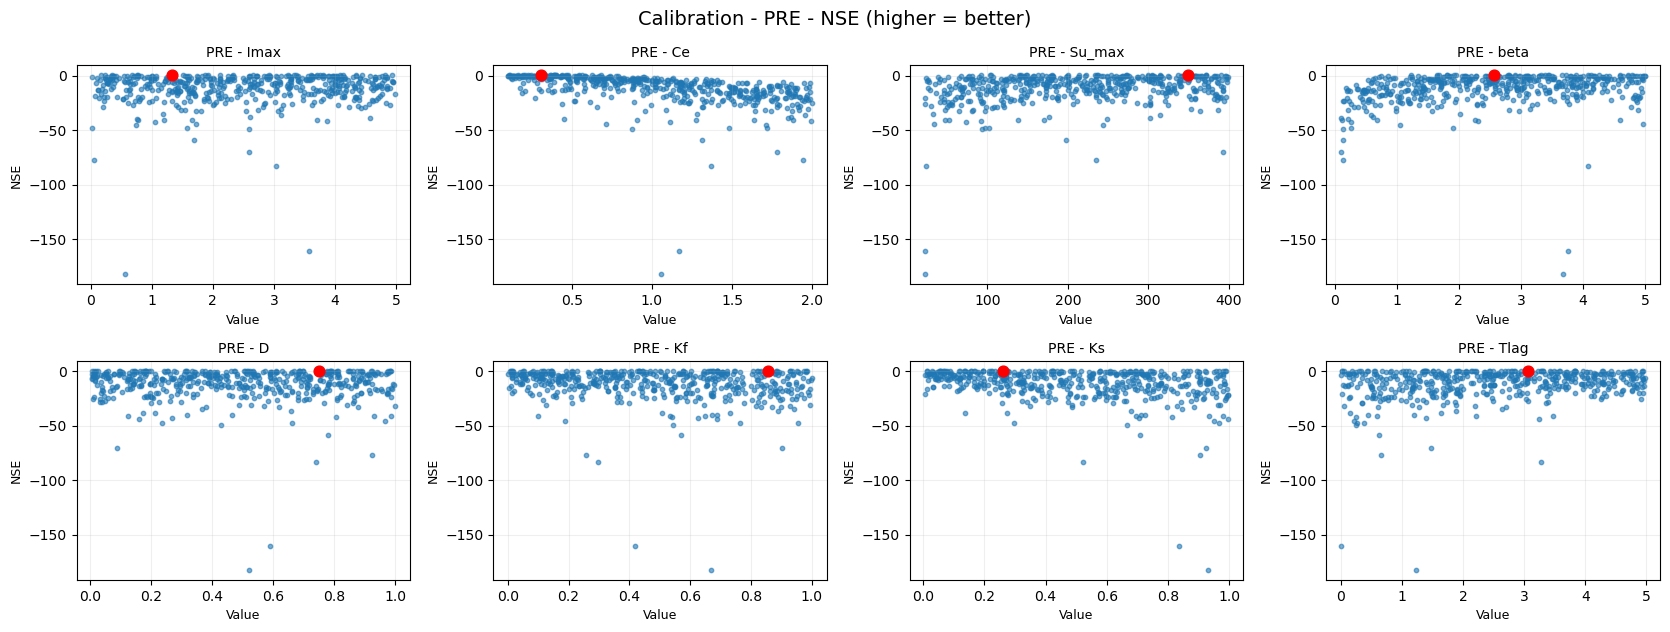

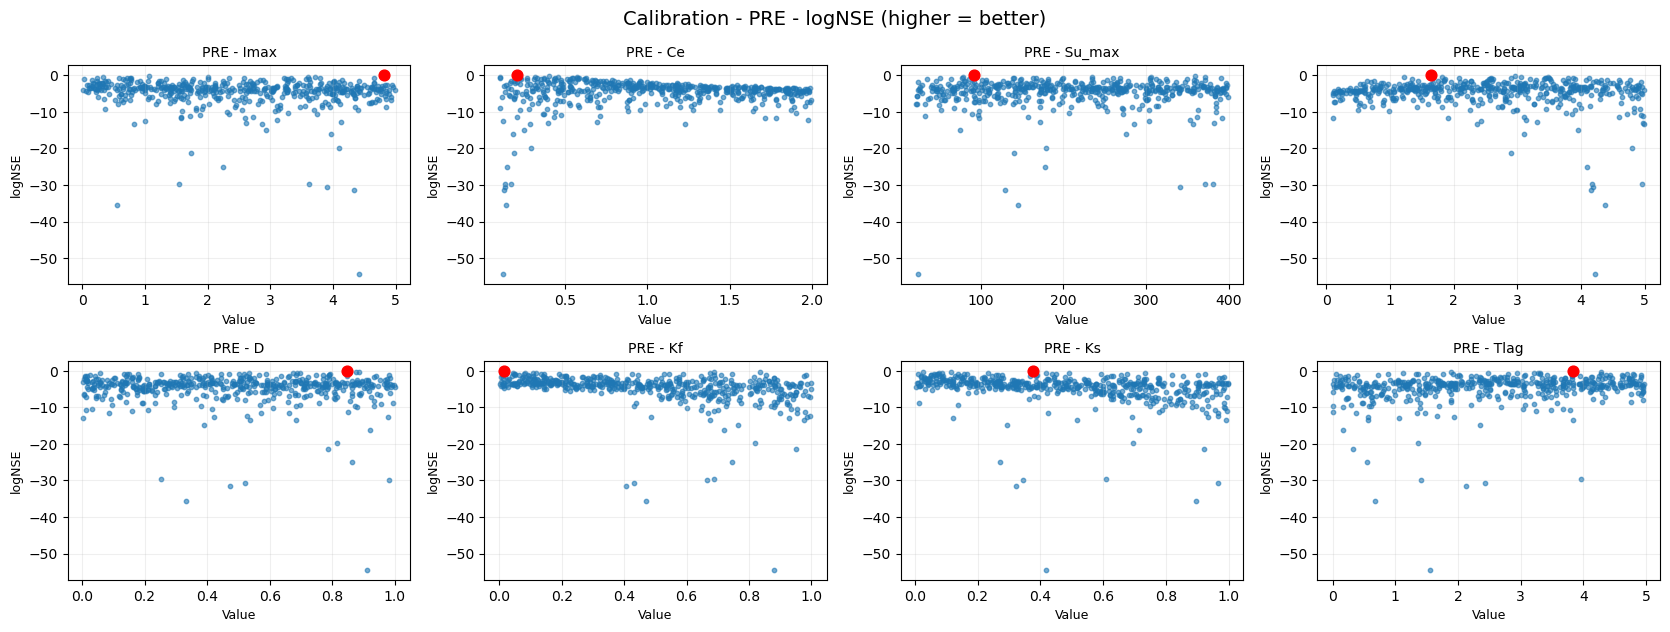

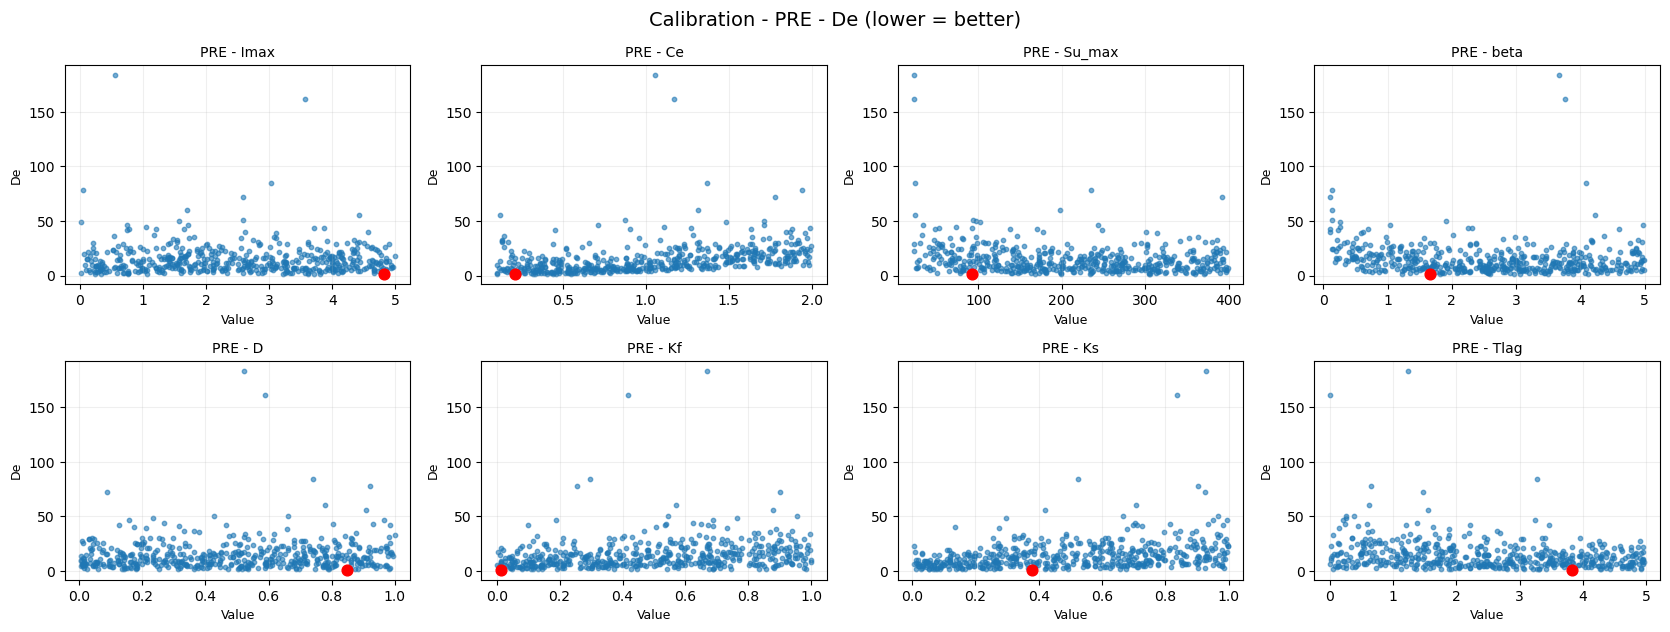

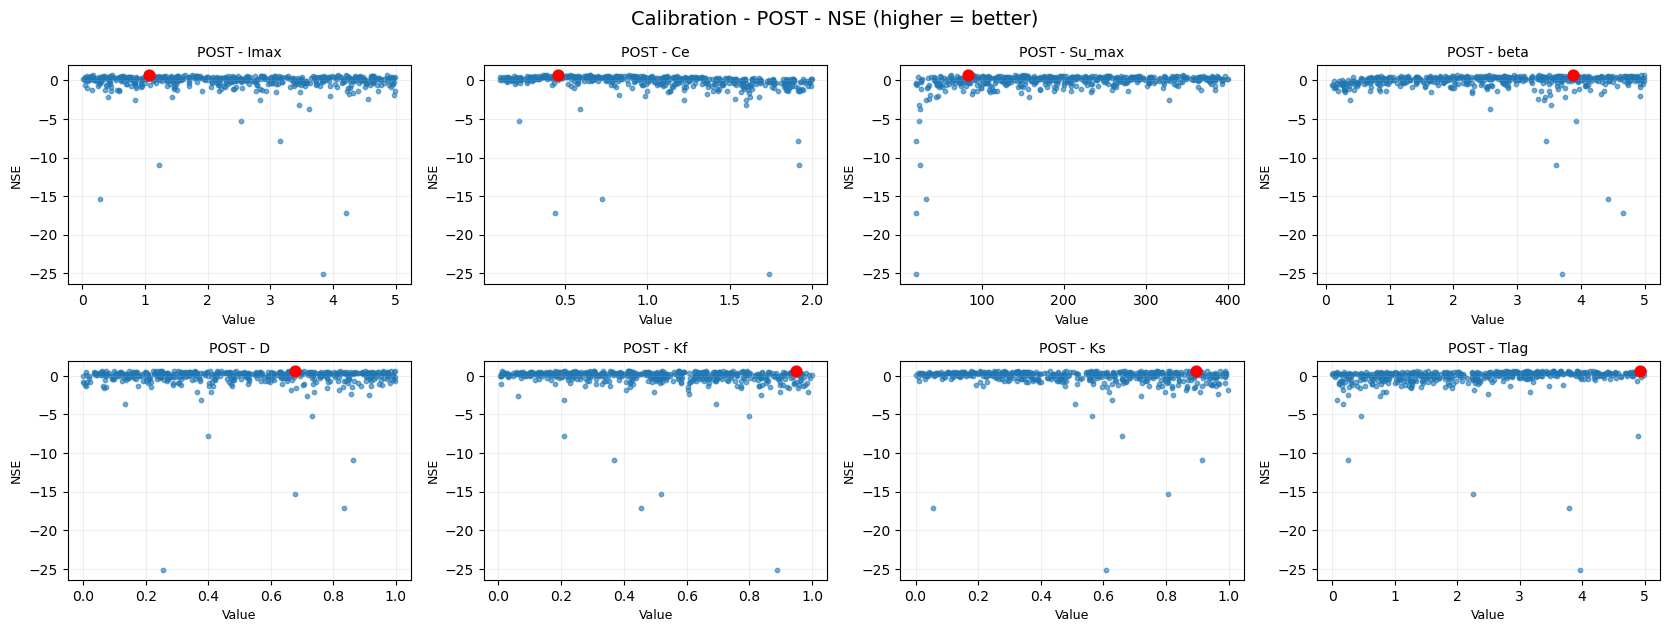

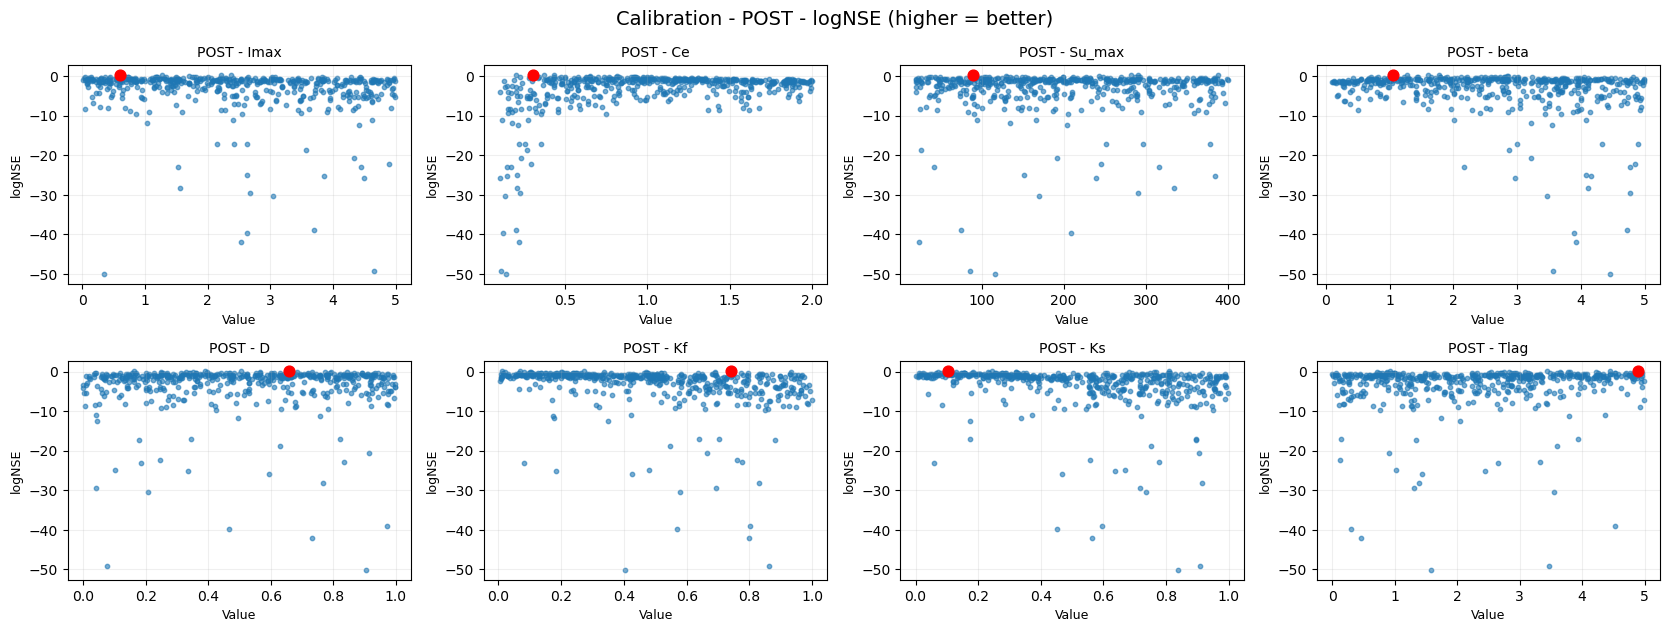

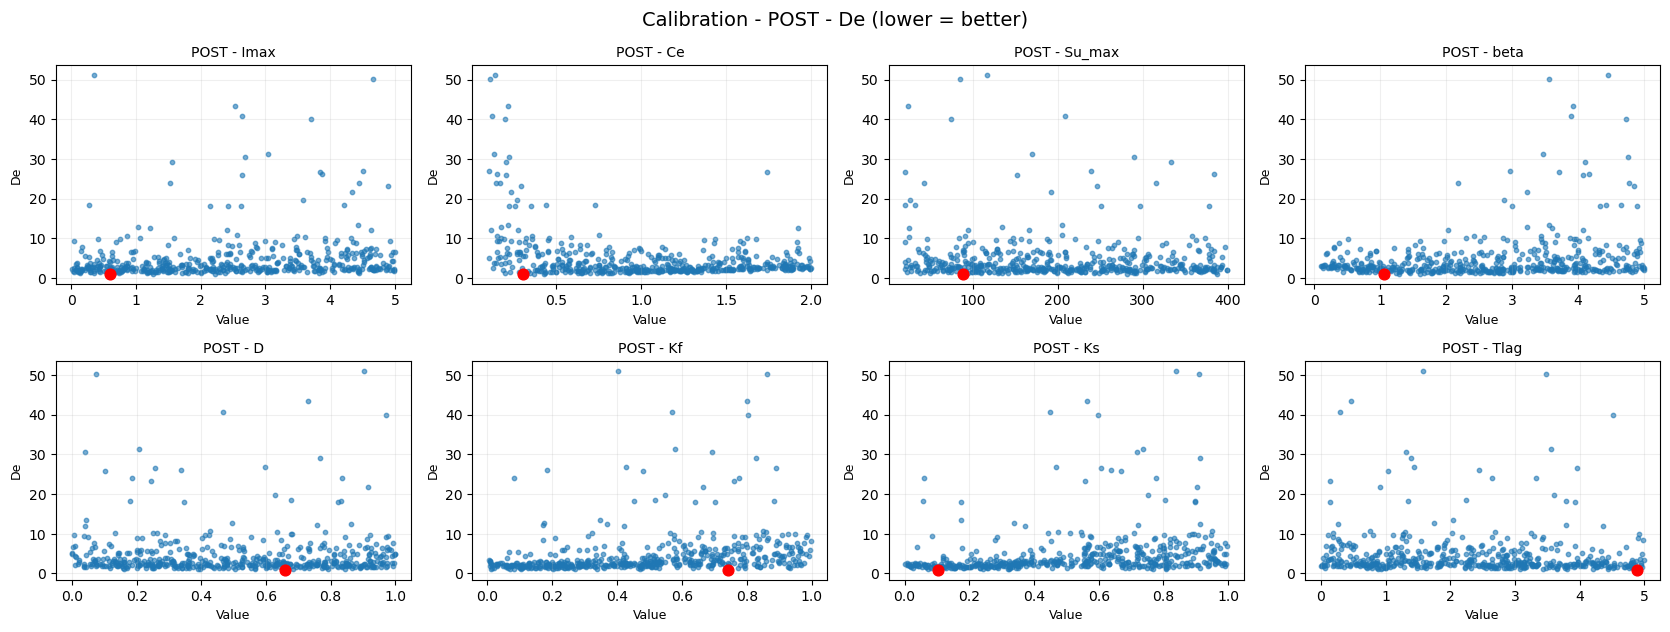

In [8]:
import math

def plot_parameter_scatter(
    thetas,
    metrics,
    param_names,
    period_label="PRE",
    metric_name="NSE",
    metric_idx=0,
    higher_is_better=True
):
    n_params = len(param_names)
    ncols = 4
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).flatten()

    y = metrics[:, metric_idx]
    # best index
    if higher_is_better:
        best_idx = np.nanargmax(y)
    else:
        best_idx = np.nanargmin(y)

    for i, pname in enumerate(param_names):
        ax = axes[i]
        x = thetas[:, i]

        ax.scatter(x, y, s=10, alpha=0.6)
        ax.scatter(
            x[best_idx], y[best_idx],
            s=60, color="red", zorder=5
        )

        ax.set_title(f"{period_label} - {pname}", fontsize=10)
        ax.set_xlabel("Value", fontsize=9)
        ax.set_ylabel(metric_name, fontsize=9)
        ax.grid(alpha=0.2)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    direction = "higher = better" if higher_is_better else "lower = better"
    fig.suptitle(f"Calibration - {period_label} - {metric_name} ({direction})", fontsize=14)
    plt.tight_layout()
    plt.show()
plot_parameter_scatter(
    thetas_pre, metrics_pre, param_names,
    period_label="PRE",
    metric_name="NSE",
    metric_idx=0,
    higher_is_better=True)

plot_parameter_scatter(
    thetas_pre, metrics_pre, param_names,
    period_label="PRE",
    metric_name="logNSE",
    metric_idx=1,
    higher_is_better=True)

plot_parameter_scatter(
    thetas_pre, metrics_pre, param_names,
    period_label="PRE",
    metric_name="De",
    metric_idx=2,
    higher_is_better=False)

plot_parameter_scatter(
    thetas_post, metrics_post, param_names,
    period_label="POST",
    metric_name="NSE",
    metric_idx=0,
    higher_is_better=True)

plot_parameter_scatter(
    thetas_post, metrics_post, param_names,
    period_label="POST",
    metric_name="logNSE",
    metric_idx=1,
    higher_is_better=True)

plot_parameter_scatter(
    thetas_post, metrics_post, param_names,
    period_label="POST",
    metric_name="De",
    metric_idx=2,
    higher_is_better=False)